[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/raulpg14/Quantum-Internet-Network-Simulator/blob/master/notebooks/01_degree_distribution.ipynb)

# Degree distribution analysis — OFBQI and SBQI
Notebook for analysing and comparing degree distributions of OFBQI and SBQI quantum network structures.
Compatible with local Jupyter and Google Colab.

In [1]:
import sys
try:
    import qcn
except ImportError:
    import subprocess
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--quiet',
        'git+https://github.com/raulpg14/Quantum-Internet-Network-Simulator.git'
    ])
    import qcn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from qcn.engine.simulation import run_simulation
from qcn.engine.config import (
    NETWORK_TYPE_OFBQI, NETWORK_TYPE_SBQI,
    SIM_MODE_DISTRIBUTION, STYLE_MAP,
    DEFAULT_RADIUS_DISTRIBUTION,
)
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [3]:
# --- Simulation parameters ---
NODES = 1000
RADIUS = DEFAULT_RADIUS_DISTRIBUTION
MC_REPS = 10
SEED = 42
# -----------------------------

In [4]:
results = {}
for net_type in [NETWORK_TYPE_OFBQI, NETWORK_TYPE_SBQI]:
    res = run_simulation({
        'nodes': NODES,
        'radius': RADIUS,
        'type': net_type,
        'mc_iter': MC_REPS,
        'sim_mode': SIM_MODE_DISTRIBUTION,
        'seed': SEED,
    })
    if res.get('success'):
        results[net_type] = res
        print(f"{net_type}: OK — density={res['density_val']:.6f}")
    else:
        print(f"{net_type}: ERROR — {res.get('error')}")

OFBQI: OK — density=0.000200
SBQI: OK — density=0.000200


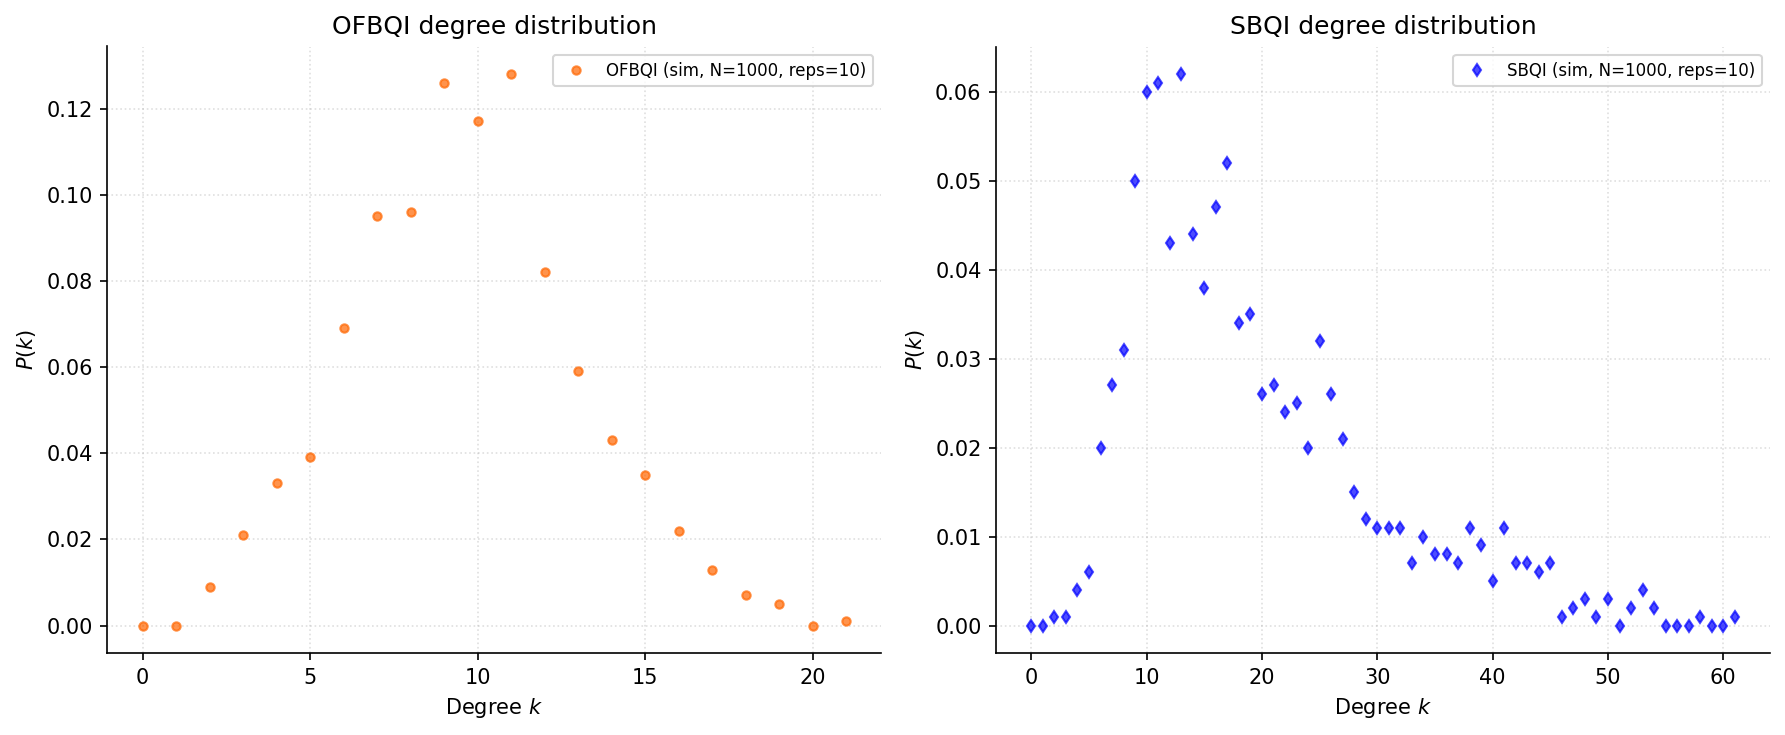

Figure saved to degree_distribution.pdf


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, net_type in zip(axes, [NETWORK_TYPE_OFBQI, NETWORK_TYPE_SBQI]):
    if net_type not in results:
        continue
    res = results[net_type]
    style = STYLE_MAP[net_type]
    ax.plot(res['dist_x'], res['dist_y'],
            color=style['color'], marker=style['marker'],
            linestyle='', markersize=4, alpha=0.7,
            label=f"{style['label']} (sim, N={NODES}, reps={MC_REPS})")
    ax.set_xlabel('Degree $k$')
    ax.set_ylabel('$P(k)$')
    ax.set_title(f'{net_type} degree distribution')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('degree_distribution.pdf')
plt.show()
print('Figure saved to degree_distribution.pdf')

## Results summary

In [6]:
print(f"{'Network':<10} {'Nodes':>8} {'Radius':>10} {'Density':>12} {'Seed':>6}")
print('-' * 52)
for net_type, res in results.items():
    print(f"{net_type:<10} {res['final_n']:>8} {res['final_radius']:>10.1f} {res['density_val']:>12.6f} {res.get('seed','N/A'):>6}")

Network       Nodes     Radius      Density   Seed
----------------------------------------------------
OFBQI          1000     1261.0     0.000200     42
SBQI           1000     1261.0     0.000200     42
